In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Custom color palette
COLORS = {
    'primary': '#003366',
    'secondary': '#FFB612',
    'success': '#28A745',
    'danger': '#DC3545',
    'warning': '#FFC107',
    'info': '#17A2B8'
}

In [7]:
# Load training and test data - ROBUST VERSION
# The actual data starts at line 20 with the header

# First, find where data starts using the 'class' header
def find_header_line(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('class,') or line.strip().startswith('class\t'):
                return i
    return 20  # Default based on your output

train_start = find_header_line('../data/raw/train.csv')
test_start = find_header_line('../data/raw/test.csv')

print(f"Header found at line: {train_start}")

# Load with robust settings
train_df = pd.read_csv(
    '../data/raw/train.csv', 
    skiprows=train_start,
    on_bad_lines='warn',  # Warn instead of error on bad lines
    low_memory=False,      # Use less memory but more robust
    encoding='utf-8'
)

test_df = pd.read_csv(
    '../data/raw/test.csv', 
    skiprows=test_start,
    on_bad_lines='warn',
    low_memory=False,
    encoding='utf-8'
)

print("="*60)
print("📊 DATASET INFORMATION")
print("="*60)
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"Total features: {train_df.shape[1] - 1}")  # Excluding target

# Show first few rows to verify
print("\n📊 First 5 rows of training data:")
train_df.head()

Header found at line: 20
📊 DATASET INFORMATION
Training set shape: (60000, 171)
Test set shape: (16000, 171)
Total features: 170

📊 First 5 rows of training data:


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,ag_009,ah_000,ai_000,aj_000,ak_000,al_000,am_0,an_000,ao_000,ap_000,aq_000,ar_000,as_000,at_000,au_000,av_000,ax_000,ay_000,ay_001,ay_002,ay_003,ay_004,ay_005,ay_006,ay_007,ay_008,ay_009,az_000,az_001,az_002,az_003,az_004,az_005,az_006,az_007,az_008,az_009,ba_000,ba_001,ba_002,ba_003,ba_004,ba_005,ba_006,ba_007,ba_008,ba_009,bb_000,bc_000,bd_000,be_000,bf_000,bg_000,bh_000,bi_000,bj_000,bk_000,bl_000,bm_000,bn_000,bo_000,bp_000,bq_000,br_000,bs_000,bt_000,bu_000,bv_000,bx_000,by_000,bz_000,ca_000,cb_000,cc_000,cd_000,ce_000,cf_000,cg_000,ch_000,ci_000,cj_000,ck_000,cl_000,cm_000,cn_000,cn_001,cn_002,cn_003,cn_004,cn_005,cn_006,cn_007,cn_008,cn_009,co_000,cp_000,cq_000,cr_000,cs_000,cs_001,cs_002,cs_003,cs_004,cs_005,cs_006,cs_007,cs_008,cs_009,ct_000,cu_000,cv_000,cx_000,cy_000,cz_000,da_000,db_000,dc_000,dd_000,de_000,df_000,dg_000,dh_000,di_000,dj_000,dk_000,dl_000,dm_000,dn_000,do_000,dp_000,dq_000,dr_000,ds_000,dt_000,du_000,dv_000,dx_000,dy_000,dz_000,ea_000,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,0,37250,1432864,3664156,1007684,25896,0,2551696,0,0,0,0,0,4933296,3655166,1766008,1132040,0,0,0,0,1012,268,0,0,0,0,0,469014,4239660,703300,755876,0,5374,2108,4114,12348,615248,5526276,2378,4,0,0,2328746,1022304,415432,287230,310246,681504,1118814,3574,0,0,6700214,0,10,108,50,2551696,97518,947550,799478,330760,353400,299160,305200,283680,na,na,na,178540,76698.08,6700214,6700214,6599892,43566,68656,54064,638360,6167850,1209600,246244,2,96,0,5245752,0,916567.68,6,1924,0,0,0,118196,1309472,3247182,1381362,98822,11208,1608,220,240,6700214,na,10476,1226,267998,521832,428776,4015854,895240,26330,118,0,532,734,4122704,51288,0,532572,0,18,5330690,4732,1126,0,0,0,0,0,0,0,0,62282,85908,32790,0,0,202710,37928,14745580,1876644,0,0,0,0,2801180,2445.8,2712,965866,1706908,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,0,18254,653294,1720800,516724,31642,0,1393352,0,68,0,0,0,2560898,2127150,1084598,338544,0,0,0,0,0,0,0,0,0,0,0,71510,772720,1996924,99560,0,7336,7808,13776,13086,1010074,1873902,14726,6,0,0,1378576,447166,199512,154298,137280,138668,165908,229652,87082,4708,3646660,86,454,364,350,1393352,49028,688314,392208,341420,359780,366560,na,na,na,na,na,6700,33057.51,3646660,3646660,3582034,17733.0,260120,115626,6900,2942850,1209600,0,na,na,na,2291079.36,0,643536.96,0,0,0,0,38,98644,1179502,1286736,336388,36294,5192,56,na,0,3646660,na,6160,796,164860,350066,272956,1837600,301242,9148,22,0,na,na,na,na,na,na,na,na,na,3312,522,0,0,0,0,0,0,0,0,33736,36946,5936,0,0,103330,16254,4510080,868538,0,0,0,0,3477820,2211.76,2334,664504,824154,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,0,1648,370592,1883374,292936,12016,0,1234132,0,0,0,0,0,2371990,2173634,300796,153698,0,0,0,0,358,110,0,0,0,0,0,0,870456,239798,1450312,0,1620,1156,1228,34250,1811606,710672,34,0,0,0,790690,672026,332340,254892,189596,135758,103552,81666,46,0,2673338,128,202,576,4,1234132,28804,160176,139730,137160,130640,na,na,na,na,na,na,28000,41040.08,2673338,2673338,2678534,15439.0,7466,22436,248240,2560566,1209600,63328,0,124,0,2322692.16,0,236099.52,0,0,0,0,0,33276,1215280,1102798,196502,10260,2422,28,0,6,2673338,na,3584,500,56362,149726,100326,1744838,488302,16682,246,0,230,292,2180528,29188,22,20346,0,0,2341048,1494,152,0,0,0,0,0,0,0,0,13876,38182,8138,0,0,65772,10534,300240,48028,0,0,0,0,1040120,1018.64,1020,262032,453378,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,318,2212,3232,1872,0,0,0,2668,0,0,0,642,3894,10184,7554,10764,1014,0,0,0,0,60,6,0,0,0,0,0,0,0,2038,5596,0,64,6,6,914,76,2478,2398,1692,0,0,6176,340,304,102,74,406,216,16,0,0,21614,2,12,0,0,2668,184,7632,3090,na,na,na,na,na,na,na,na,10580,12.69,21614,21614,21772,32,50,1994,21400,7710,120960

In [8]:
# Data types and memory usage
memory_usage = train_df.memory_usage(deep=True).sum() / 1024**2

print("📊 DATASET STATISTICS")
print("="*60)
print(f"Memory usage: {memory_usage:.2f} MB")
print(f"Number of features: {train_df.shape[1] - 1}")
print(f"Number of records: {train_df.shape[0]}")

# Data type distribution
dtype_counts = train_df.dtypes.value_counts()
print("\n📊 Data Type Distribution:")
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} columns")

📊 DATASET STATISTICS
Memory usage: 509.62 MB
Number of features: 170
Number of records: 60000

📊 Data Type Distribution:
  str: 170 columns
  int64: 1 columns


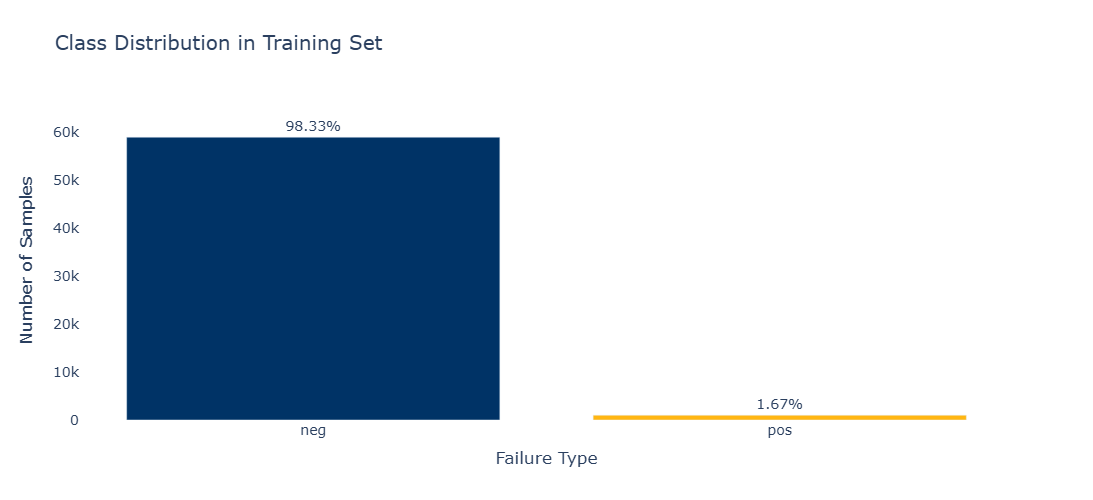

📊 CLASS DISTRIBUTION
NEG: 59,000 samples (98.33%)
POS: 1,000 samples (1.67%)

⚠️ Imbalance Ratio: 59.00:1
   (Negative is 59.00x more frequent than Positive)


In [9]:
# Class distribution
class_counts = train_df['class'].value_counts()
class_percentages = (class_counts / len(train_df) * 100).round(2)

# Create dataframe for visualization
class_df = pd.DataFrame({
    'Class': class_counts.index,
    'Count': class_counts.values,
    'Percentage': class_percentages.values
})

# Create interactive bar chart
fig = px.bar(
    class_df,
    x='Class',
    y='Count',
    text='Percentage',
    color='Class',
    color_discrete_map={'neg': '#003366', 'pos': '#FFB612'},
    title='Class Distribution in Training Set',
    labels={'Count': 'Number of Samples', 'Class': 'Failure Type'}
)

fig.update_traces(texttemplate='%{text:.2f}%', textposition='outside')
fig.update_layout(
    height=500,
    showlegend=False,
    plot_bgcolor='white',
    font=dict(size=14)
)
fig.show()

# Print statistics
print("📊 CLASS DISTRIBUTION")
print("="*60)
for idx, row in class_df.iterrows():
    print(f"{row['Class'].upper()}: {row['Count']:,} samples ({row['Percentage']:.2f}%)")
print("="*60)

imbalance_ratio = class_counts['neg'] / class_counts['pos']
print(f"\n⚠️ Imbalance Ratio: {imbalance_ratio:.2f}:1")
print(f"   (Negative is {imbalance_ratio:.2f}x more frequent than Positive)")

In [10]:
# Function to calculate missing percentages
def calculate_missing(df, dataset_name):
    # Only check numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.empty:
        print(f"⚠️ No numeric columns found in {dataset_name}")
        return pd.Series()
    
    missing = numeric_df.isna().sum() / len(df) * 100
    missing = missing[missing > 0].sort_values(ascending=False)
    
    print(f"📊 Missing Value Analysis - {dataset_name}")
    print("="*60)
    print(f"Total columns with missing values: {len(missing)}")
    print(f"Total missing values: {numeric_df.isna().sum().sum():,}")
    
    # Create categories
    categories = {
        'High (80-100%)': len(missing[missing >= 80]),
        'Medium (20-80%)': len(missing[(missing >= 20) & (missing < 80)]),
        'Low (5-20%)': len(missing[(missing >= 5) & (missing < 20)]),
        'Very Low (<5%)': len(missing[missing < 5])
    }
    
    print("\n📊 Missing Value Categories:")
    for category, count in categories.items():
        print(f"  {category}: {count} features")
    
    return missing

# Calculate missing for training and test
train_missing = calculate_missing(train_df, 'Training Set')
print("\n" + "="*60)
test_missing = calculate_missing(test_df, 'Test Set')

📊 Missing Value Analysis - Training Set
Total columns with missing values: 0
Total missing values: 0

📊 Missing Value Categories:
  High (80-100%): 0 features
  Medium (20-80%): 0 features
  Low (5-20%): 0 features
  Very Low (<5%): 0 features

📊 Missing Value Analysis - Test Set
Total columns with missing values: 0
Total missing values: 0

📊 Missing Value Categories:
  High (80-100%): 0 features
  Medium (20-80%): 0 features
  Low (5-20%): 0 features
  Very Low (<5%): 0 features


In [11]:
# Visualize missing patterns
if len(train_missing) > 0 or len(test_missing) > 0:
    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=('Training Set Missing Values', 'Test Set Missing Values'),
        vertical_spacing=0.15
    )

    for idx, (missing_data, title) in enumerate([(train_missing, 'Training'), (test_missing, 'Test')], start=1):
        if len(missing_data) > 0:
            missing_df = pd.DataFrame({
                'Feature': missing_data.index,
                'Missing %': missing_data.values
            }).head(30)
            
            fig.add_trace(
                go.Bar(
                    x=missing_df['Missing %'],
                    y=missing_df['Feature'],
                    orientation='h',
                    marker_color='#003366',
                    text=missing_df['Missing %'].round(2),
                    textposition='outside'
                ),
                row=idx, col=1
            )

    fig.update_layout(
        height=800,
        title_text='Top 30 Features with Missing Values',
        showlegend=False,
        plot_bgcolor='white',
        font=dict(size=12)
    )
    fig.update_xaxes(title_text='Missing Percentage (%)', row=1, col=1)
    fig.update_xaxes(title_text='Missing Percentage (%)', row=2, col=1)
    fig.show()
else:
    print("No missing values found in either dataset!")

No missing values found in either dataset!


In [12]:
# Select numeric features (excluding class)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'class']

print(f"📊 Number of numeric features: {len(numeric_cols)}")
print(f"Sample features: {numeric_cols[:10]}")

if len(numeric_cols) > 1:
    # Create correlation matrix
    corr_matrix = train_df[numeric_cols].corr().abs()

    # Find highly correlated pairs
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_pairs = [(col, row, upper.loc[col, row]) 
                       for col in upper.columns 
                       for row in upper.index 
                       if upper.loc[col, row] > 0.9]

    print(f"\n📊 Found {len(high_corr_pairs)} highly correlated pairs (>0.9)")
    if high_corr_pairs:
        print("\n📊 TOP 10 HIGHLY CORRELATED FEATURES:")
        for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True)[:10]:
            print(f"  {feat1} ↔ {feat2}: {corr:.3f}")
else:
    print("Not enough numeric columns for correlation analysis.")

📊 Number of numeric features: 1
Sample features: ['aa_000']
Not enough numeric columns for correlation analysis.


In [13]:
# Comprehensive summary
print("="*80)
print("📊 DATA QUALITY SUMMARY")
print("="*80)

# Size
print(f"\n📁 Dataset Size:")
print(f"  - Training: {train_df.shape[0]:,} samples")
print(f"  - Test: {test_df.shape[0]:,} samples")
print(f"  - Features: {train_df.shape[1] - 1}")

# Missing values
numeric_df = train_df.select_dtypes(include=[np.number])
if numeric_df.shape[1] > 0:
    missing_percent = (numeric_df.isna().sum().sum() / (numeric_df.shape[0] * numeric_df.shape[1]) * 100)
    print(f"\n🔍 Missing Values:")
    print(f"  - Overall missing in numeric columns: {missing_percent:.2f}%")
    high_missing = [col for col in numeric_df.columns if numeric_df[col].isna().sum() / len(numeric_df) > 0.5]
    print(f"  - Features with >50% missing: {len(high_missing)}")

# Class balance
print(f"\n⚖️ Class Balance:")
for class_val, count in class_counts.items():
    print(f"  - {class_val.upper()}: {count:,} ({count/len(train_df)*100:.2f}%)")
print(f"  - Imbalance Ratio: {class_counts['neg']/class_counts['pos']:.2f}:1")

print("\n✅ EDA Complete! Ready for Feature Engineering.")

📊 DATA QUALITY SUMMARY

📁 Dataset Size:
  - Training: 60,000 samples
  - Test: 16,000 samples
  - Features: 170

🔍 Missing Values:
  - Overall missing in numeric columns: 0.00%
  - Features with >50% missing: 0

⚖️ Class Balance:
  - NEG: 59,000 (98.33%)
  - POS: 1,000 (1.67%)
  - Imbalance Ratio: 59.00:1

✅ EDA Complete! Ready for Feature Engineering.
